In [1]:
import os
import sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(".")
print(f"Current Working Directory reset to: {os.getcwd()}")
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from torch.utils.data import DataLoader

from src.fine_tuning.lora_utils import ActivationAnalyzer, apply_selective_lora
from src.fine_tuning.train_retriver import load_raw_data, to_input_examples, train_lora_retriever

Current Working Directory reset to: /home/huynh-gia-bao/Documents/NLP-assignment


/home/huynh-gia-bao/Documents/NLP-assignment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Model and dataset path configurations
model_name = "BAAI/bge-small-en-v1.5"
train_path = "data/training/retriever_train.jsonl"
test_path = "data/training/retriever_test.jsonl"
output_path = "models/checkpoints/bge-lora-activation-guided"

print(f"Loading Base Retriever Model: {model_name}")
model = SentenceTransformer(model_name)

print("Loading Calibration Data for Activation Analysis...")
# Load raw JSONL data and convert to InputExamples for the probe pass
raw_data = load_raw_data(train_path)
calib_examples = to_input_examples(raw_data[:200]) # Use 200 representative samples

# Pack into DataLoader with a custom collate_fn to safely handle InputExample objects
calib_dataloader = DataLoader(calib_examples, shuffle=True, batch_size=8, collate_fn=lambda x: x)
print(f"Successfully prepared calibration dataloader with {len(calib_examples)} samples.")

Loading Base Retriever Model: BAAI/bge-small-en-v1.5


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 17802.42it/s]


Loading Calibration Data for Activation Analysis...
Successfully prepared calibration dataloader with 200 samples.


Analyzing activations over 25 batches...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 97.41it/s]



--- ACTIVATION VARIANCE BY LAYER (HIGHEST TO LOWEST) ---
Layer  0: Variance Score = 0.5802
Layer  1: Variance Score = 0.5799
Layer  6: Variance Score = 0.5783
Layer  7: Variance Score = 0.5725
Layer  3: Variance Score = 0.5668
Layer 10: Variance Score = 0.5660
Layer  2: Variance Score = 0.5565
Layer  4: Variance Score = 0.5477
Layer  5: Variance Score = 0.5335
Layer  8: Variance Score = 0.5257
Layer  9: Variance Score = 0.5114
Layer 11: Variance Score = 0.4718


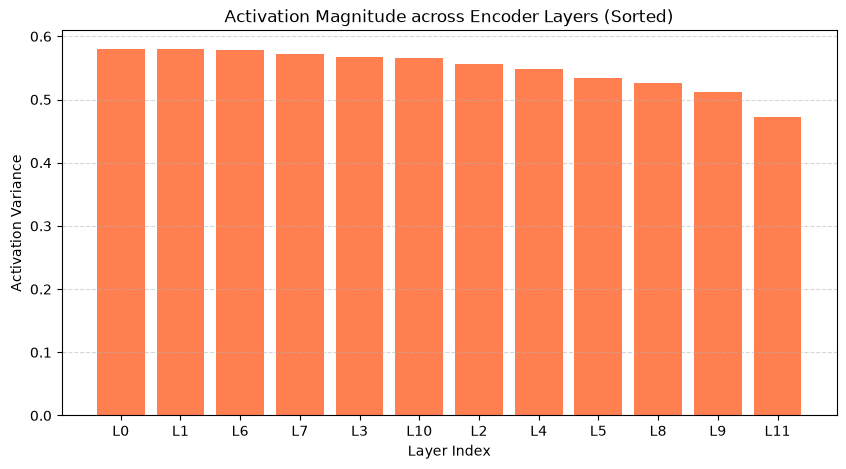

In [3]:
# Initialize the analyzer and run forward pass to calculate layer variance
analyzer = ActivationAnalyzer(model)
sorted_layers = analyzer.analyze(calib_dataloader, num_batches=25)

print("\n--- ACTIVATION VARIANCE BY LAYER (HIGHEST TO LOWEST) ---")
layers, scores = [], []
for layer_idx, score in sorted_layers:
    print(f"Layer {layer_idx:2d}: Variance Score = {score:.4f}")
    layers.append(f"L{layer_idx}")
    scores.append(score)

# Plot the activation magnitudes across all layers
plt.figure(figsize=(10, 5))
plt.bar(layers, scores, color='coral')
plt.title("Activation Magnitude across Encoder Layers (Sorted)")
plt.xlabel("Layer Index")
plt.ylabel("Activation Variance")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [4]:
# Select the Top 6 layers showing the highest activation variance
TOP_K = 6 
selected_layers = [layer_idx for layer_idx, score in sorted_layers[:TOP_K]]
selected_layers.sort() # Ensure ascending order for structural PEFT transformation

print(f"-> FINAL SELECTED LAYERS FOR LORA ADAPTER INJECTION: {selected_layers}")

# Apply LoRA to the selected layers and freeze the unselected modules
model = apply_selective_lora(model, target_layers=selected_layers, r=16)

-> FINAL SELECTED LAYERS FOR LORA ADAPTER INJECTION: [0, 1, 3, 6, 7, 10]
Injecting LoRA adapters into layers: [0, 1, 3, 6, 7, 10]
trainable params: 147,456 || all params: 33,507,456 || trainable%: 0.4401


Loading raw dataset from data/training/retriever_train.jsonl...
Dataset split complete -> Train samples: 189 | Validation samples: 81



--- STARTING LORA FINE-TUNING ---


Step,Training Loss,Validation Loss,Val Cosine Accuracy@1,Val Cosine Accuracy@3,Val Cosine Precision@1,Val Cosine Precision@3,Val Cosine Recall@1,Val Cosine Recall@3,Val Cosine Ndcg@10,Val Cosine Mrr@10,Val Cosine Map@100
5,0.795553,0.458597,0.925926,0.987654,0.925926,0.329218,0.925926,0.987654,0.964872,0.956790,0.957912
10,0.731835,0.405043,0.925926,0.987654,0.925926,0.329218,0.925926,0.987654,0.964872,0.956790,0.957912
15,0.332711,0.343245,0.925926,0.987654,0.925926,0.329218,0.925926,0.987654,0.968441,0.958025,0.958025
20,0.528478,0.278635,0.938272,0.987654,0.938272,0.329218,0.938272,0.987654,0.969429,0.962963,0.964085
25,0.373740,0.216739,0.950617,0.987654,0.950617,0.329218,0.950617,0.987654,0.973985,0.969136,0.970258
30,0.295594,0.164483,0.901235,0.987654,0.901235,0.329218,0.901235,0.987654,0.959476,0.945816,0.945816
35,0.147771,0.125401,0.913580,0.987654,0.913580,0.329218,0.913580,0.987654,0.964431,0.952381,0.952381
40,0.423519,0.100305,0.901235,0.987654,0.901235,0.329218,0.901235,0.987654,0.960157,0.946502,0.946502
45,0.204219,0.083408,0.925926,0.987654,0.925926,0.329218,0.925926,0.987654,0.969270,0.958848,0.958848
50,0.204214,0.070967,0.913580,0.987654,0.913580,0.329218,0.913580,0.987654,0.965633,0.953704,0.953704


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 175/175 [00:00<00:00, 13702.78it/s]
[transformers] BertModel LOAD REPORT from: models/checkpoints/bge-lora-activation-guided/checkpoint-25
Key                                                                          | Status     | 
-----------------------------------------------------------------------------+------------+-
encoder.layer.{0, 1, 3, 6, 7, 10}.attention.self.query.base_layer.bias       | UNEXPECTED | 
encoder.layer.{0, 1, 3, 6, 7, 10}.attention.self.value.lora_B.default.weight | UNEXPECTED | 
encoder.layer.{0, 1, 3, 6, 7, 10}.attention.self.value.base_layer.bias       | UNEXPECTED | 
encoder.layer.{0, 1, 3, 6, 7, 10}.attention.self.value.lora_A.default.weight | UNEXPECTED | 
encoder.layer.{0, 1, 3, 6, 7, 10}.attention.self.value.base_layer.weight     | UNEXPECTED | 
encoder.layer.{0, 1, 3, 6, 7, 10}.attention.self.query.lora_A.default.weight 


Training completed. Best model loaded automatically (based on MRR@10).


Writing model shards: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.83it/s]


Lightweight LoRA adapter saved to: models/checkpoints/bge-lora-activation-guided/lora_adapter
Training plot successfully saved to: models/checkpoints/bge-lora-activation-guided/training_metrics_plot.png


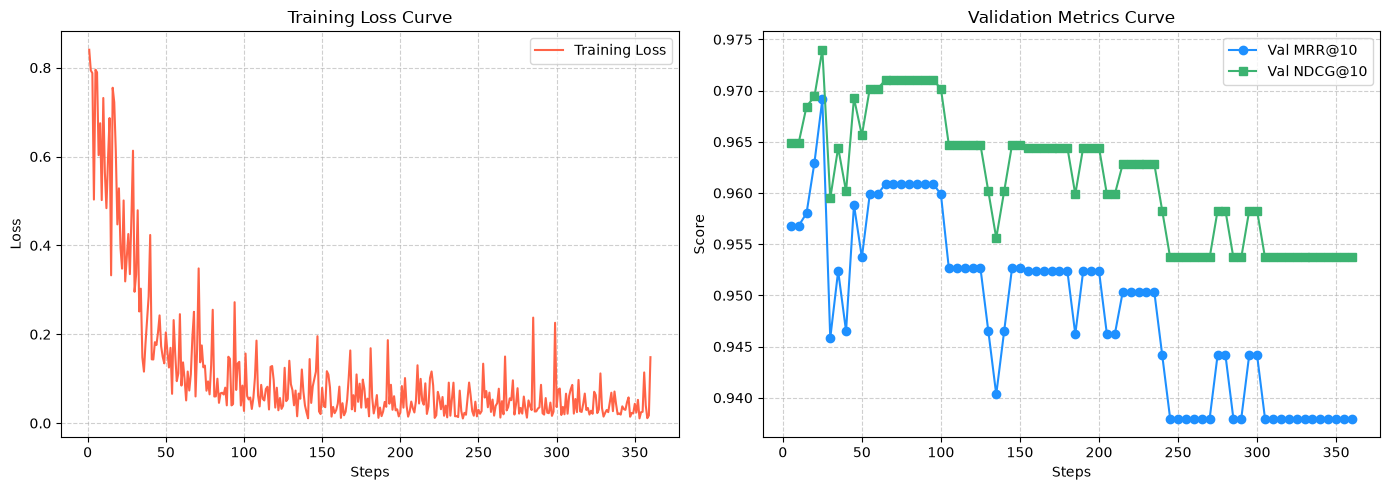


--- RUNNING FINAL EVALUATION ON TEST SET: data/training/retriever_test.jsonl ---

--- Final Test Set Metrics ---
 - test_cosine_accuracy@1: 0.9667
 - test_cosine_accuracy@3: 1.0000
 - test_cosine_precision@1: 0.9667
 - test_cosine_precision@3: 0.3333
 - test_cosine_recall@1: 0.9667
 - test_cosine_recall@3: 1.0000
 - test_cosine_ndcg@10: 0.9877
 - test_cosine_mrr@10: 0.9833
 - test_cosine_map@100: 0.9833


In [5]:
train_lora_retriever(
    model=model,
    train_path=train_path,
    test_path=test_path,     
    output_path=output_path,
    batch_size=16,            
    epochs=30,                # Train for 30 epochs as requested
    lr=2e-4,                  
    val_ratio=0.3             # 30% of training data becomes the Validation split
)